# Hafta 14: Makine Öğrenmesi III: Güvenilir Model Kurma — Pipeline, Veri Sızıntısı, Hiperparametre, Dengesiz Veri

**Biyoenformatiğe Giriş (Python & Biopython)**

**Bu haftanın hedefleri**
1. **Veri sızıntısını (data leakage)** tanımak ve `Pipeline` ile önlemek.
2. `GridSearchCV` ile hiperparametre ayarı yapmak; iç içe (nested) çapraz doğrulamanın neden gerektiğini görmek.
3. Çok sınıflı problemlerde makro/ağırlıklı ölçütleri kullanmak (tümör alt tipi sınıflandırma).
4. Özellik seçimi yapıp seçilen genleri **bilinen biyolojik belirteçlerle** karşılaştırmak; yığın etkisini denetlemek.
5. Dengesiz veride (antimikrobiyal peptit tahmini) doğru ölçüt, sınıf ağırlığı ve karar eşiği seçmek.

**Veri:** `tumor_ifade.csv`, `tumor_etiketler.csv`, `tumor_marker_genler.csv`, `peptitler.csv` (600 peptit, %25 AMP)

> **Kullanım:** Colab'da *Çalışma zamanı → Tümünü çalıştır* ile tüm hücreleri sırayla çalıştırabilirsiniz. Alıştırmaların çözümleri notebook'un sonundadır; önce kendiniz deneyin.

In [1]:
# Colab'da gerekli kütüphaneleri kur (yalnızca ilk çalıştırmada birkaç saniye sürer)
!pip -q install biopython 
import Bio
print('Biopython sürümü:', Bio.__version__)

Biopython sürümü: 1.88


In [2]:
# ---------------- VERİ SETİNİ HAZIRLA ----------------
# Veri dosyaları ders paketindeki 'veri' klasöründe de mevcuttur.
# İsterseniz Colab'ın sol panelinden 'veri' klasörü oluşturup dosyaları yükleyebilirsiniz;
# dosya bulunamazsa aşağıdaki fonksiyon(lar) AYNI veriyi (sabit tohum) yeniden üretir.
import os

def veri_uret_tumor(klasor="veri"):
    """tumor_ifade.csv (200 örnek x 1000 gen, log2 ölçek), tumor_etiketler.csv, tumor_marker_genler.csv"""
    import os
    import numpy as np
    import pandas as pd
    os.makedirs(klasor, exist_ok=True)
    rng = np.random.default_rng(12)
    G = 1000
    tipler = {"A": 70, "B": 60, "C": 45, "D": 25}
    genler = [f"g{i:04d}" for i in range(1, G + 1)]
    mu = rng.normal(7, 1.5, G)
    sd = rng.uniform(0.5, 1.1, G)
    # gen modülleri: ortak gizli faktörlerle korelasyon
    faktor_yuk = np.zeros((G, 5))
    for k in range(5):
        idx = rng.choice(G, 80, replace=False)
        faktor_yuk[idx, k] = rng.uniform(0.2, 0.5, 80)
    marker = {}
    kalan = list(rng.permutation(G))
    for t in tipler:
        marker[t] = [kalan.pop() for _ in range(30)]
    ortak_CD = [kalan.pop() for _ in range(20)]            # C ve D alt tiplerinin ortak belirteçleri
    satirlar, etiket, merkez = [], [], []
    for t, n in tipler.items():
        for _ in range(n):
            x = mu + sd * rng.normal(size=G) + faktor_yuk @ rng.normal(size=5)
            idx = marker[t]
            if t in ("A", "B"):                             # belirgin alt tipler
                x[idx[:20]] += rng.uniform(0.7, 1.4, 20)
                x[idx[20:]] -= rng.uniform(0.7, 1.4, 10)
            else:                                           # C ve D birbirine benzer, farkları zayıf
                x[ortak_CD] += rng.uniform(0.7, 1.4, 20)
                x[idx[:20]] += rng.uniform(0.25, 0.6, 20)
                x[idx[20:]] -= rng.uniform(0.25, 0.6, 10)
            m = "Merkez1" if rng.random() < 0.55 else "Merkez2"
            if m == "Merkez2":
                x[:120] += 0.6                             # yığın (batch) etkisi
            satirlar.append(x); etiket.append(t); merkez.append(m)
    X = np.round(np.array(satirlar), 3)
    sira = rng.permutation(len(X))
    ornek = [f"TMR{i:03d}" for i in range(1, len(X) + 1)]
    pd.DataFrame(X[sira], index=pd.Index(ornek, name="ornek"), columns=genler).to_csv(
        os.path.join(klasor, "tumor_ifade.csv"))
    pd.DataFrame({"ornek": ornek, "alt_tip": np.array(etiket)[sira],
                  "merkez": np.array(merkez)[sira]}).to_csv(
        os.path.join(klasor, "tumor_etiketler.csv"), index=False)
    pd.DataFrame([(genler[g], t, "yukari" if i < 20 else "asagi")
                  for t, lst in marker.items() for i, g in enumerate(lst)]
                 + [(genler[g], "C+D", "yukari") for g in ortak_CD],
                 columns=["gen", "alt_tip", "yon"]).to_csv(
        os.path.join(klasor, "tumor_marker_genler.csv"), index=False)


def veri_uret_peptit(klasor="veri"):
    """peptitler.csv: 600 peptit; amp=1 antimikrobiyal peptit (dengesiz: 150 pozitif)"""
    import os, random, csv
    os.makedirs(klasor, exist_ok=True)
    rng = random.Random(8)
    aa = "ACDEFGHIKLMNPQRSTVWY"
    arka = [8.3, 1.4, 5.5, 6.8, 3.9, 7.1, 2.3, 5.9, 5.8, 9.7, 2.4, 4.1, 4.7, 3.9, 5.4, 6.6, 5.3, 6.9, 1.1, 2.9]
    amp = list(arka)
    for harf, kat in {"K": 2.6, "R": 2.4, "L": 1.5, "W": 2.5, "I": 1.6, "F": 1.4, "C": 1.8,
                      "D": 0.35, "E": 0.35, "Q": 0.6, "N": 0.6}.items():
        amp[aa.index(harf)] *= kat
    satirlar = []
    for i in range(600):
        pozitif = i < 150
        n = rng.randint(12, 40)
        w = amp if pozitif else arka
        if not pozitif and rng.random() < 0.15:              # zor negatifler: katyonik ama AMP değil
            w = [x * (1.8 if a in "KR" else 1) for a, x in zip(aa, arka)]
        s = "".join(rng.choices(aa, weights=w, k=n))
        satirlar.append((f"pep_{i+1:03d}", s, int(pozitif)))
    rng.shuffle(satirlar)
    with open(os.path.join(klasor, "peptitler.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["id", "dizi", "amp"])
        w.writerows(satirlar)


if not os.path.exists('veri/tumor_ifade.csv'):
    veri_uret_tumor()
    veri_uret_peptit()
print('veri klasörü:', sorted(os.listdir('veri')))


veri klasörü: ['1A8O.pdb', 'peptitler.csv', 'tumor_etiketler.csv', 'tumor_ifade.csv', 'tumor_marker_genler.csv']


## 1. Veri sızıntısı: en sinsi hata
Test (veya doğrulama) verisinden gelen bilgi, modelin eğitim sürecine **herhangi bir yoldan** sızarsa başarı olduğundan yüksek görünür.

| Sızıntı türü | Örnek | Doğrusu |
|---|---|---|
| Ön işleme sızıntısı | Tüm veriyi ölçekleyip sonra bölmek | Ölçekleyiciyi yalnızca eğitim katmanında `fit` etmek |
| **Özellik seçimi sızıntısı** | Tüm veride en ayırt edici genleri seçip sonra CV yapmak | Seçimi her CV katmanının içinde yapmak |
| Grup sızıntısı | Aynı hastanın örnekleri hem eğitimde hem testte | `GroupKFold` |
| Homoloji sızıntısı | Neredeyse aynı proteinler eğitim ve testte | Dizi benzerliğine göre kümeleyip küme bazında bölmek |

Aşağıda tamamen **rastgele** veride sızıntının ne kadar yanıltıcı olabileceğini gösteriyoruz.

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, cross_val_predict

rng = np.random.default_rng(1)
Xr = rng.normal(size=(100, 5000))          # 100 "hasta", 5000 rastgele "gen"
yr = rng.integers(0, 2, 100)               # rastgele etiket -> gerçek başarı %50 olmalı
cv = StratifiedKFold(5, shuffle=True, random_state=0)

# YANLIŞ: özellik seçimi tüm veride
secilen = SelectKBest(f_classif, k=20).fit(Xr, yr).get_support()
yanlis = cross_val_score(LogisticRegression(max_iter=2000), Xr[:, secilen], yr, cv=cv).mean()
# DOĞRU: seçim pipeline içinde
dogru_pipe = make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000))
dogru = cross_val_score(dogru_pipe, Xr, yr, cv=cv).mean()
print(f"Sızıntılı CV doğruluğu : {yanlis:.2f}   <-- rastgele veride imkânsız derecede yüksek!")
print(f"Pipeline CV doğruluğu  : {dogru:.2f}   <-- gerçekçi (≈0.5)")

Sızıntılı CV doğruluğu : 0.92   <-- rastgele veride imkânsız derecede yüksek!
Pipeline CV doğruluğu  : 0.58   <-- gerçekçi (≈0.5)


## 2. Tümör alt tipi sınıflandırma (çok sınıflı)

In [4]:
X = pd.read_csv("veri/tumor_ifade.csv", index_col=0)
et = pd.read_csv("veri/tumor_etiketler.csv").set_index("ornek").loc[X.index]
marker = pd.read_csv("veri/tumor_marker_genler.csv")
y = et.alt_tip.values
print(X.shape, pd.Series(y).value_counts().to_dict())

from sklearn.model_selection import train_test_split
X_egt, X_test, y_egt, y_test, m_egt, m_test = train_test_split(X, y, et.merkez.values, test_size=0.25, stratify=y, random_state=7)
print("Eğitim:", X_egt.shape, "| Test:", X_test.shape)

(200, 1000) {'A': 70, 'B': 60, 'C': 45, 'D': 25}
Eğitim: (150, 1000) | Test: (50, 1000)


### 2.1 Pipeline + GridSearchCV
```
Pipeline:  StandardScaler  →  SelectKBest(f_classif, k=?)  →  Sınıflandırıcı(C=?)
GridSearchCV: her (k, C) kombinasyonu için 5 katlı CV → en iyi kombinasyon → tüm eğitim verisiyle yeniden eğit
```

In [5]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

pipe = Pipeline([("olcek", StandardScaler()), ("sec", SelectKBest(f_classif)), ("model", LogisticRegression(max_iter=5000))])
izgara = [
    {"sec__k": [10, 50, 200, 1000], "model": [LogisticRegression(max_iter=5000)], "model__C": [0.01, 0.1, 1]},
    {"sec__k": [10, 50, 200, 1000], "model": [SVC(kernel="rbf")], "model__C": [0.1, 1, 10]},
    {"sec__k": [50, 200], "model": [RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)]},
]
arama = GridSearchCV(pipe, izgara, cv=cv, scoring="f1_macro", n_jobs=-1).fit(X_egt, y_egt)
print("En iyi parametreler:", {k: (v if not hasattr(v, "fit") else type(v).__name__) for k, v in arama.best_params_.items()})
print(f"En iyi CV makro-F1: {arama.best_score_:.3f}")
sonuclar = pd.DataFrame(arama.cv_results_)
sonuclar["model_adi"] = sonuclar.param_model.map(lambda m: type(m).__name__)
sonuclar.groupby(["model_adi", "param_sec__k"]).mean_test_score.max().unstack().round(3)

En iyi parametreler: {'model': 'LogisticRegression', 'model__C': 1, 'sec__k': 200}
En iyi CV makro-F1: 0.931


param_sec__k,10,50,200,1000
model_adi,,,,
LogisticRegression,0.717,0.747,0.931,0.836
RandomForestClassifier,NaN,0.761,0.790,NaN
SVC,0.705,0.765,0.910,0.664


### 2.2 Neden iç içe (nested) CV?
GridSearchCV'nin `best_score_` değeri **iyimserdir**: aynı CV katmanları hem parametre seçmek hem de başarıyı ölçmek için kullanıldı.
Tarafsız tahmin için dış döngüde ayrı bir CV gerekir:
```
Dış CV (5 katman) ─┬─ eğitim kısmı → İç CV (GridSearchCV) → en iyi model
                   └─ test kısmı   → bu modelin başarısı
```

In [6]:
kucuk_izgara = {"sec__k": [50, 200], "model__C": [0.01, 0.1, 1]}
ic = GridSearchCV(Pipeline([("olcek", StandardScaler()), ("sec", SelectKBest(f_classif)), ("model", LogisticRegression(max_iter=5000))]),
                  kucuk_izgara, cv=StratifiedKFold(3, shuffle=True, random_state=1), scoring="f1_macro")
ic_ice = cross_val_score(ic, X_egt, y_egt, cv=cv, scoring="f1_macro")
print(f"İç içe CV makro-F1: {ic_ice.mean():.3f} ± {ic_ice.std():.3f}")

İç içe CV makro-F1: 0.931 ± 0.043


              precision    recall  f1-score   support

           A      1.000     1.000     1.000        18
           B      1.000     1.000     1.000        15
           C      0.846     1.000     0.917        11
           D      1.000     0.667     0.800         6

    accuracy                          0.960        50
   macro avg      0.962     0.917     0.929        50
weighted avg      0.966     0.960     0.958        50



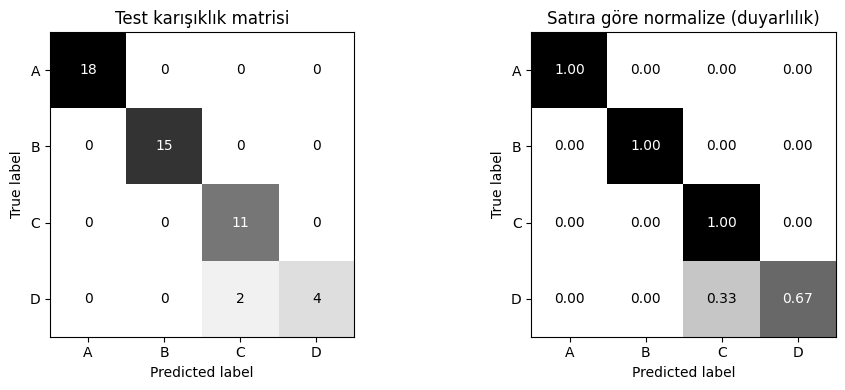

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, balanced_accuracy_score
en_iyi = arama.best_estimator_
tahmin = en_iyi.predict(X_test)
print(classification_report(y_test, tahmin, digits=3))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, tahmin, cmap="Greys", ax=ax[0], colorbar=False); ax[0].set_title("Test karışıklık matrisi")
ConfusionMatrixDisplay.from_predictions(y_test, tahmin, cmap="Greys", ax=ax[1], colorbar=False, normalize="true", values_format=".2f")
ax[1].set_title("Satıra göre normalize (duyarlılık)"); plt.tight_layout(); plt.show()

### Makro ve ağırlıklı ortalama — sayısal örnek
Üç sınıfın F1 skorları: A = 0.95 (n = 70), B = 0.90 (n = 60), D = 0.50 (n = 10).
* **Makro F1** = (0.95 + 0.90 + 0.50)/3 = **0.783** (her sınıf eşit ağırlıkta → az örnekli sınıftaki kötü başarıyı gösterir)
* **Ağırlıklı F1** = (70·0.95 + 60·0.90 + 10·0.50)/140 = **0.896** (büyük sınıflar baskın)

In [8]:
print("Makro F1   :", round((0.95 + 0.90 + 0.50) / 3, 3))
print("Ağırlıklı F1:", round((70 * 0.95 + 60 * 0.90 + 10 * 0.50) / 140, 3))

Makro F1   : 0.783
Ağırlıklı F1: 0.896


## 3. Özellik seçimi ve biyolojik doğrulama
Veri üretilirken her alt tip için 30 **belirteç (marker) gen** tanımlanmıştı. Modelin seçtiği genler bunlarla örtüşüyor mu?

In [9]:
k_sec = 60
p_sec = Pipeline([("olcek", StandardScaler()), ("sec", SelectKBest(f_classif, k=k_sec))]).fit(X_egt, y_egt)
secilen_genler = X.columns[p_sec.named_steps["sec"].get_support()]
gercek_marker = set(marker.gen)
print(f"ANOVA F ile seçilen {k_sec} genden {len(set(secilen_genler) & gercek_marker)} tanesi gerçek belirteç "
      f"(kesinlik = {len(set(secilen_genler) & gercek_marker)/k_sec:.2f}); rastgele seçimde beklenen ≈ {k_sec*len(gercek_marker)/X.shape[1]:.1f}")

# L1 (lasso) düzenlileştirmeli lojistik regresyon: gömülü özellik seçimi
l1 = make_pipeline(StandardScaler(), LogisticRegression(penalty="l1", solver="saga", C=0.2, max_iter=5000)).fit(X_egt, y_egt)
katsayi = pd.DataFrame(l1[-1].coef_, index=l1[-1].classes_, columns=X.columns)
sifir_olmayan = katsayi.columns[(katsayi.abs() > 0).any()]
print(f"L1-LR {len(sifir_olmayan)} gen kullandı; bunların {len(set(sifir_olmayan) & gercek_marker)} tanesi gerçek belirteç. "
      f"Test makro-F1 = {f1_score(y_test, l1.predict(X_test), average='macro'):.3f}")

ANOVA F ile seçilen 60 genden 60 tanesi gerçek belirteç (kesinlik = 1.00); rastgele seçimde beklenen ≈ 8.4


L1-LR 63 gen kullandı; bunların 59 tanesi gerçek belirteç. Test makro-F1 = 0.889


In [10]:
# Her alt tip için en büyük pozitif katsayılı genler, o alt tipin belirteçleri mi?
satir = []
for t in katsayi.index:
    ilk = katsayi.loc[t].sort_values(ascending=False).head(10).index
    dogru = marker[(marker.alt_tip == t) & (marker.gen.isin(ilk))]
    satir.append({"alt tip": t, "ilk 10 gen içinde kendi belirteci": len(dogru), "örnek genler": ", ".join(ilk[:5])})
pd.DataFrame(satir)

,alt tip,ilk 10 gen içinde kendi belirteci,örnek genler
0,A,10,"g0106, g0716, g0799, g0129, g0746"
1,B,9,"g0126, g0765, g0100, g0160, g0697"
2,C,6,"g0320, g0439, g0158, g0015, g0273"
3,D,5,"g0666, g0548, g0826, g0476, g0623"


## 4. Yığın (merkez) etkisi denetimi
Model alt tipi mi, yoksa örneğin hangi merkezde işlendiğini mi öğreniyor? İki kontrol:
1. İfade verisinden **merkez** tahmin edilebiliyor mu? (Evetse teknik sinyal var.)
2. Alt tip modelinin başarısı merkezler arasında farklı mı?

In [11]:
merkez_modeli = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1))
print("Merkez tahmin doğruluğu (CV):", cross_val_score(merkez_modeli, X, et.merkez, cv=cv).mean().round(3), "-> teknik sinyal güçlü!")
for mz in ["Merkez1", "Merkez2"]:
    m = m_test == mz
    print(f"{mz}: test örneği={m.sum():3d}, alt tip makro-F1={f1_score(y_test[m], tahmin[m], average='macro'):.3f}")
print("Alt tip × merkez çapraz tablosu:\n", pd.crosstab(et.alt_tip, et.merkez))

Merkez tahmin doğruluğu (CV): 1.0 -> teknik sinyal güçlü!
Merkez1: test örneği= 32, alt tip makro-F1=0.885
Merkez2: test örneği= 18, alt tip makro-F1=1.000
Alt tip × merkez çapraz tablosu:
 merkez   Merkez1  Merkez2
alt_tip                  
A             33       37
B             36       24
C             29       16
D             14       11


> Merkez mükemmel tahmin edilebiliyor, ama alt tiplerle **dengeli dağıldığı** için (çapraz tablo) alt tip modeli bundan
yararlanamıyor; merkezler arasındaki küçük başarı farkı, az sayıdaki D örneğinin hangi merkeze düştüğüyle ilgili. Eğer bir alt tipin örneklerinin çoğu tek bir merkezden gelseydi, model merkezi öğrenip "başarılı" görünebilirdi (**karıştırıcı / confounding**).
Deney tasarımında örneklerin gruplar arasında dengeli dağıtılması bu yüzden kritiktir.

## 5. Dengesiz veri: antimikrobiyal peptit (AMP) tahmini
Pozitif sınıf %25. Gerçek hayatta (ör. genom boyunca AMP taraması) bu oran çok daha düşüktür.

| Ölçüt | Dengesiz veride |
|---|---|
| Doğruluk | Yanıltıcı ("hepsi negatif" %75 alır) |
| Dengeli doğruluk | (duyarlılık + özgüllük)/2 |
| F1, kesinlik-duyarlılık eğrisi, **Ortalama Kesinlik (AP)** | Pozitif sınıfa odaklı |
| Matthews korelasyon katsayısı (MCC) | Dört hücrenin tamamını kullanır; −1..+1 |

$MCC = \dfrac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$

**Sayısal örnek:** TP = 20, FN = 10, FP = 5, TN = 85 → MCC = (1700 − 50)/√(25·30·90·95) = 1650/√6 412 500 = 1650/2532.3 = **0.652**.

In [12]:
from sklearn.metrics import matthews_corrcoef
print("MCC örneği:", round(matthews_corrcoef([1]*30 + [0]*90, [1]*20 + [0]*10 + [1]*5 + [0]*85), 3))

from Bio.SeqUtils.ProtParam import ProteinAnalysis
AA = "ACDEFGHIKLMNPQRSTVWY"
pep = pd.read_csv("veri/peptitler.csv")
def ozellik(s):
    pa = ProteinAnalysis(s)
    return [s.count(a) / len(s) for a in AA] + [len(s), pa.charge_at_pH(7.0), pa.gravy(), pa.isoelectric_point(), pa.aromaticity()]
Fp = np.array([ozellik(s) for s in pep.dizi])
yp = pep.amp.values
print("Peptit özellikleri:", Fp.shape, "| pozitif oranı:", yp.mean())
Fp_egt, Fp_test, yp_egt, yp_test = train_test_split(Fp, yp, test_size=0.3, stratify=yp, random_state=3)

MCC örneği: 0.652
Peptit özellikleri: (600, 25) | pozitif oranı: 0.25


In [13]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, average_precision_score, recall_score, precision_score

adaylar = {
    "Çoğunluk sınıfı (baz)": DummyClassifier(strategy="most_frequent"),
    "LR": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "LR, class_weight=balanced": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced")),
    "RF": RandomForestClassifier(400, random_state=0, n_jobs=-1),
    "RF, class_weight=balanced": RandomForestClassifier(400, random_state=0, n_jobs=-1, class_weight="balanced"),
}
satir = []
for ad, m in adaylar.items():
    m.fit(Fp_egt, yp_egt); t = m.predict(Fp_test); p = m.predict_proba(Fp_test)[:, 1]
    satir.append({"model": ad, "doğruluk": accuracy_score(yp_test, t), "dengeli doğ.": balanced_accuracy_score(yp_test, t),
                  "kesinlik": precision_score(yp_test, t, zero_division=0), "duyarlılık": recall_score(yp_test, t),
                  "F1": f1_score(yp_test, t), "MCC": matthews_corrcoef(yp_test, t), "AP": average_precision_score(yp_test, p)})
pd.DataFrame(satir).set_index("model").round(3)

,doğruluk,dengeli doğ.,kesinlik,duyarlılık,F1,MCC,AP
model,,,,,,,
Çoğunluk sınıfı (baz),0.750,0.500,0.000,0.000,0.000,0.000,0.250
LR,0.856,0.793,0.732,0.667,0.698,0.604,0.793
"LR, class_weight=balanced",0.833,0.807,0.642,0.756,0.694,0.584,0.803
RF,0.861,0.789,0.763,0.644,0.699,0.613,0.829
"RF, class_weight=balanced",0.867,0.785,0.800,0.622,0.700,0.624,0.814


> Çoğunluk sınıfı tahmincisi %75 doğruluk alıyor ama hiçbir AMP bulamıyor (duyarlılık 0, MCC 0). `class_weight="balanced"` duyarlılığı artırır,
karşılığında kesinlik düşebilir. Hangi ödünleşimin doğru olduğu **uygulamaya** bağlıdır: laboratuvarda test edilecek aday sayısı sınırlıysa kesinlik,
hiçbir adayı kaçırmamak önemliyse duyarlılık önceliklidir.

### Karar eşiğini seçmek
Varsayılan 0.5 eşiği her zaman en iyisi değildir. Eşik **eğitim verisi üzerinde CV tahminleriyle** seçilmeli, test verisi kullanılmamalıdır.

CV ile seçilen eşik: 0.42
eşik=0.50: kesinlik=0.642 duyarlılık=0.756 F1=0.694 MCC=0.584
eşik=0.42: kesinlik=0.649 duyarlılık=0.822 F1=0.725 MCC=0.627


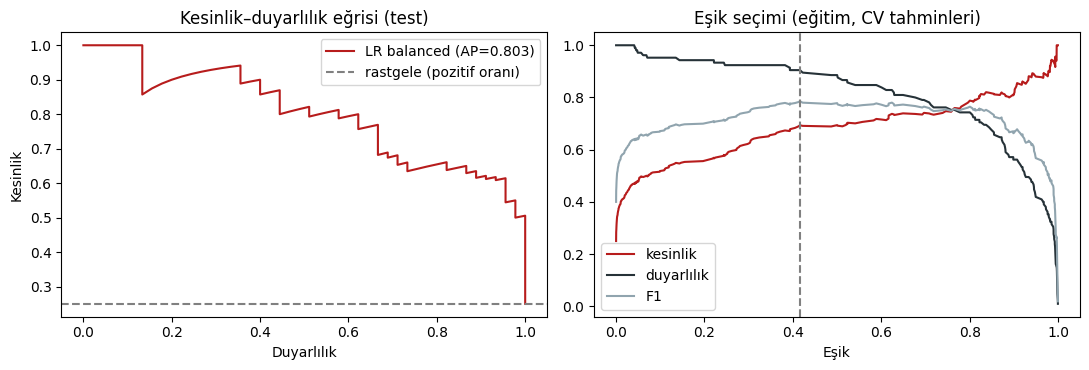

In [14]:
from sklearn.metrics import precision_recall_curve
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced"))
p_cv = cross_val_predict(model, Fp_egt, yp_egt, cv=cv, method="predict_proba")[:, 1]    # yalnızca eğitim verisi
kes, duy, esik = precision_recall_curve(yp_egt, p_cv)
f1 = 2 * kes * duy / (kes + duy + 1e-12)
en_iyi_esik = esik[np.argmax(f1[:-1])]
print(f"CV ile seçilen eşik: {en_iyi_esik:.2f}")

model.fit(Fp_egt, yp_egt); p_test = model.predict_proba(Fp_test)[:, 1]
for e in [0.5, en_iyi_esik]:
    t = (p_test >= e).astype(int)
    print(f"eşik={e:.2f}: kesinlik={precision_score(yp_test, t):.3f} duyarlılık={recall_score(yp_test, t):.3f} F1={f1_score(yp_test, t):.3f} MCC={matthews_corrcoef(yp_test, t):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
kt, dt, _ = precision_recall_curve(yp_test, p_test)
ax[0].plot(dt, kt, color="#b71c1c", label=f"LR balanced (AP={average_precision_score(yp_test, p_test):.3f})")
ax[0].axhline(yp_test.mean(), ls="--", color="gray", label="rastgele (pozitif oranı)")
ax[0].set_xlabel("Duyarlılık"); ax[0].set_ylabel("Kesinlik"); ax[0].legend(); ax[0].set_title("Kesinlik–duyarlılık eğrisi (test)")
ax[1].plot(esik, kes[:-1], label="kesinlik", color="#b71c1c"); ax[1].plot(esik, duy[:-1], label="duyarlılık", color="#263238")
ax[1].plot(esik, f1[:-1], label="F1", color="#90a4ae"); ax[1].axvline(en_iyi_esik, ls="--", color="gray")
ax[1].set_xlabel("Eşik"); ax[1].legend(); ax[1].set_title("Eşik seçimi (eğitim, CV tahminleri)")
plt.tight_layout(); plt.show()

## 6. Modeli kaydetmek ve yeniden kullanmak

In [15]:
import joblib
joblib.dump({"model": model, "esik": float(en_iyi_esik), "ozellikler": AA + " + uzunluk,yuk,gravy,pI,aromatiklik"}, "amp_modeli.joblib")
yuklenen = joblib.load("amp_modeli.joblib")
yeni = ["GIGKFLHSAKKFGKAFVGEIMNS", "KWKLFKKIGAVLKVL", "MSTEQDLAANGSPEVD"]     # magainin-2, bir sentetik katyonik peptit, rastgele
p = yuklenen["model"].predict_proba(np.array([ozellik(s) for s in yeni]))[:, 1]
for s, pi in zip(yeni, p):
    print(f"{s:25s} P(AMP)={pi:.2f} -> {'AMP adayı' if pi >= yuklenen['esik'] else 'değil'}")

GIGKFLHSAKKFGKAFVGEIMNS   P(AMP)=0.51 -> AMP adayı
KWKLFKKIGAVLKVL           P(AMP)=1.00 -> AMP adayı
MSTEQDLAANGSPEVD          P(AMP)=0.00 -> değil


## 7. Kontrol listesi: güvenilir bir biyoinformatik ML çalışması
- [ ] Test verisi en başta ayrıldı ve yalnızca en sonda bir kez kullanıldı
- [ ] Tüm ön işleme + özellik seçimi `Pipeline` içinde
- [ ] Sınıf dengesizliğine uygun ölçüt (F1, MCC, AP) ve katmanlı (stratified) bölme
- [ ] Hiperparametreler iç CV ile, başarı dış CV / test ile ölçüldü
- [ ] Basit bir baz (baseline) modelle karşılaştırıldı
- [ ] Homoloji / hasta / yığın gibi grup yapıları dikkate alındı
- [ ] Önemli özellikler biyolojik olarak yorumlandı
- [ ] Rastgele tohumlar ve yazılım sürümleri raporlandı

## 8. Alıştırmalar
1. TP = 45, FN = 5, FP = 45, TN = 405 için doğruluk, kesinlik, duyarlılık, F1 ve MCC'yi elle hesaplayın.
2. Sızıntı deneyini k = 5, 20, 100, 500 seçilen özellik için tekrarlayın. Sızıntılı ve pipeline doğruluklarını aynı grafikte çizin.
3. Tümör verisinde yalnızca **D** alt tipinin (az örnekli) duyarlılığını artırmak için `class_weight="balanced"` kullanın. Makro-F1 değişti mi?
4. `GroupKFold` kullanarak "merkez bazında" doğrulama yapın: Merkez1'de eğitip Merkez2'de test edin (ve tersi). Başarı düştü mü? Neden?
5. Peptit modelinde 5 fizikokimyasal özelliği çıkarıp yalnızca amino asit bileşimini kullanın. AP ne kadar değişti?

---
## Çözümler

1) doğruluk=0.900 kesinlik=0.500 duyarlılık=0.900 F1=0.643 MCC=0.625


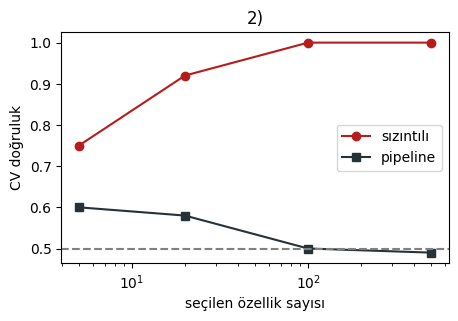

3) balanced makro-F1: 0.966 | D duyarlılığı: 0.833
4) Merkez1 -> Merkez2: makro-F1 = 0.917
4) Merkez2 -> Merkez1: makro-F1 = 0.798
5) sadece bileşim AP: 0.809 | tüm özellikler AP: 0.803


In [16]:
# 1
TP, FN, FP, TN = 45, 5, 45, 405
P_, R_ = TP / (TP + FP), TP / (TP + FN)
mcc = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
print(f"1) doğruluk={(TP+TN)/500:.3f} kesinlik={P_:.3f} duyarlılık={R_:.3f} F1={2*P_*R_/(P_+R_):.3f} MCC={mcc:.3f}")
# 2
kl = [5, 20, 100, 500]; ys, ds = [], []
for k in kl:
    s = SelectKBest(f_classif, k=k).fit(Xr, yr).get_support()
    ys.append(cross_val_score(LogisticRegression(max_iter=2000), Xr[:, s], yr, cv=cv).mean())
    ds.append(cross_val_score(make_pipeline(SelectKBest(f_classif, k=k), LogisticRegression(max_iter=2000)), Xr, yr, cv=cv).mean())
plt.figure(figsize=(5, 3)); plt.semilogx(kl, ys, "o-", label="sızıntılı", color="#b71c1c"); plt.semilogx(kl, ds, "s-", label="pipeline", color="#263238")
plt.axhline(0.5, ls="--", color="gray"); plt.xlabel("seçilen özellik sayısı"); plt.ylabel("CV doğruluk"); plt.legend(); plt.title("2)"); plt.show()
# 3
b = make_pipeline(StandardScaler(), SelectKBest(f_classif, k=200), LogisticRegression(max_iter=5000, C=0.1, class_weight="balanced")).fit(X_egt, y_egt)
print("3) balanced makro-F1:", round(f1_score(y_test, b.predict(X_test), average="macro"), 3),
      "| D duyarlılığı:", round(recall_score(y_test, b.predict(X_test), labels=["D"], average=None)[0], 3))
# 4
for egt, tst in [("Merkez1", "Merkez2"), ("Merkez2", "Merkez1")]:
    me, mt = (et.merkez == egt).values, (et.merkez == tst).values
    m4 = make_pipeline(StandardScaler(), SelectKBest(f_classif, k=200), LogisticRegression(max_iter=5000, C=0.1)).fit(X[me], y[me])
    print(f"4) {egt} -> {tst}: makro-F1 = {f1_score(y[mt], m4.predict(X[mt]), average='macro'):.3f}")
# 5
m5 = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced")).fit(Fp_egt[:, :20], yp_egt)
print("5) sadece bileşim AP:", round(average_precision_score(yp_test, m5.predict_proba(Fp_test[:, :20])[:, 1]), 3),
      "| tüm özellikler AP:", round(average_precision_score(yp_test, p_test), 3))